In [ ]:
https://colab.research.google.com/drive/1j_VcnP2FLcBLVQsIEsYqC-oMCg6asIhN

In [ ]:
!pip install mediapipe opencv-python-headless
import mediapipe as mp
print(mp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
0.10.35


In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
print("MediaPipe Tasks API works!")

MediaPipe Tasks API works!


In [ ]:
import urllib.request
import os

url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
urllib.request.urlretrieve(url, "face_landmarker.task")
print("Model downloaded.")

base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    running_mode=vision.RunningMode.IMAGE
)

landmarker = vision.FaceLandmarker.create_from_options(options)
print("FaceLandmarker created successfully!")

Model downloaded.
FaceLandmarker created successfully!


In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import urllib.request
from google.colab.patches import cv2_imshow


# Load and process
image = mp.Image.create_from_file("viber_image_2026-02-05_21-01-07-358.jpg")

results = landmarker.detect(image)
print(f"Faces detected: {len(results.face_landmarks)}")

if results.face_landmarks:
    print(f"Landmarks per face: {len(results.face_landmarks[0])}")
    print("Detection successful!")

Faces detected: 1
Landmarks per face: 478
Detection successful!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving viber_image_2026-02-05_21-01-07-358.jpg to viber_image_2026-02-05_21-01-07-358.jpg


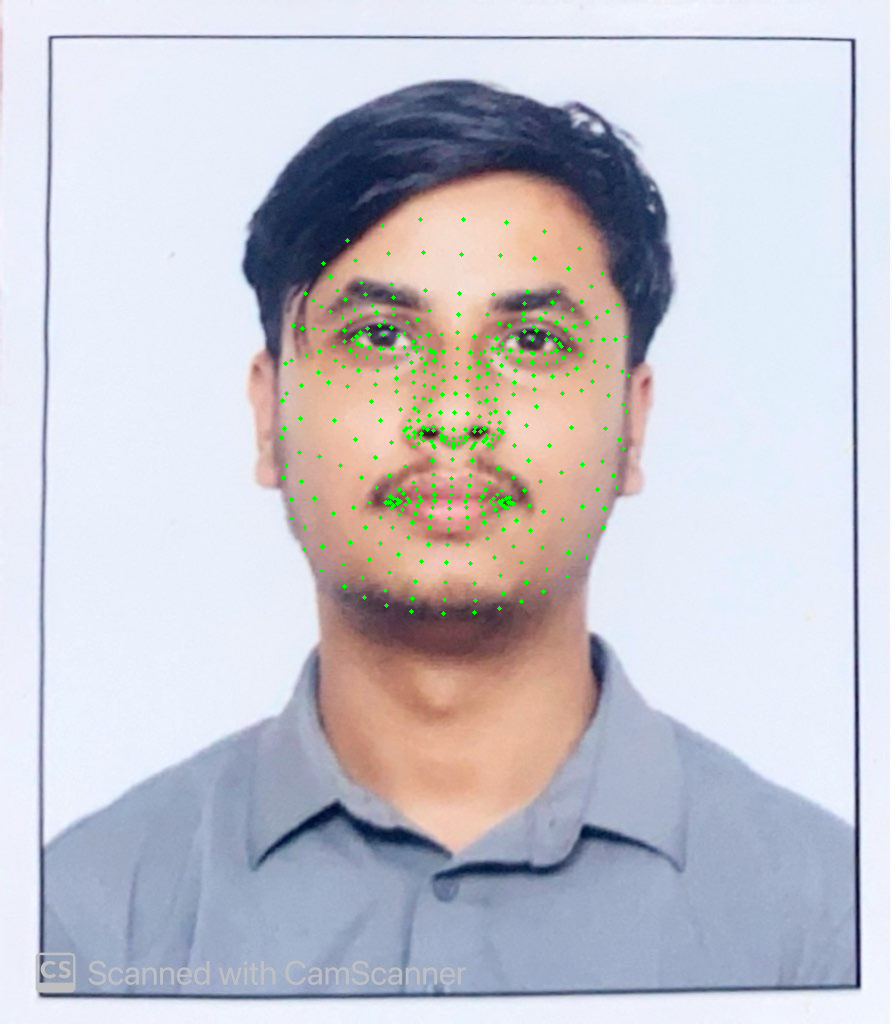

Landmarks drawn successfully!


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load image with OpenCV
frame = cv2.imread("viber_image_2026-02-05_21-01-07-358.jpg")
h, w, _ = frame.shape

# Draw landmarks
for face_landmarks in results.face_landmarks:
    for landmark in face_landmarks:
        x = int(landmark.x * w)
        y = int(landmark.y * h)
        cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)

cv2_imshow(frame)
print("Landmarks drawn successfully!")